# Notebook 08 – XGBoost Recovery Tier Classifier (Branch 3: ML)

**Objective:** Train XGBoost to predict the 5-tier Recovery Tier for each customer by combining signals from all three branches.

**Inputs:**
- `data/processed/07_with_distress_scores.csv` — base features + FinBERT distress scores (30K × 94)
- `data/processed/06_with_stress_vectors.csv` — BiLSTM stress dims + anomaly flag (30K × 122, BiLSTM cols merged in)

**Output:** `data/processed/08_with_recovery_tiers.csv` — adds `recovery_tier` column  
**Model:** `models/xgboost/best_model.json`

---

## Recovery Tier Definitions

| Tier | Label | Rule (priority order, highest first) |
|------|-------|--------------------------------------|
| 5 | Strategic Default | default=1 AND distress_avg < 0.33 AND bilstm_anomaly_flag=1 |
| 4 | Severe Genuine Distress | distress_level=severe OR (default=1 AND distress_level=high) |
| 3 | Hardship | distress_level=high AND default=0 |
| 2 | Soft Assist | distress_level=moderate |
| 1 | Standard Reminder | distress_level=low |

**Note on leakage prevention:** `default payment next month`, `distress_level`, and `distress_encoded` are used to engineer the target and are excluded from the feature set. Numeric distress scores (distress_avg, distress_turn_*) are model outputs — safe to keep as features.

**Note on Sparkov:** Raw Sparkov data has zero customer_id overlap with our 30K customers. Its contribution is already embedded as `sp_*` columns assigned during Phase A3. The raw file is not used here.

---

In [22]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score
)
from sklearn.utils.class_weight import compute_sample_weight
import shap

print(f'XGBoost version: {xgb.__version__}')
print(f'SHAP version:    {shap.__version__}')

XGBoost version: 3.2.0
SHAP version:    0.51.0


In [23]:
# Cell 2: Configuration

CONFIG = {
    # ----- Input Files -----
    'finbert_path':  '../../../data/processed/07_with_distress_scores.csv',
    'bilstm_path':   '../../../data/processed/06_with_stress_vectors.csv',

    # ----- Output -----
    'output_path':   '../../../data/processed/08_with_recovery_tiers.csv',
    'model_dir':     '../../../models/xgboost',
    'manifest_path': '../../../models/xgboost/xgboost_manifest.json',

    # ----- Shared Split -----
    'split_path':    '../../../models/bilstm/train_val_indices.npz',

    # ----- Tier Engineering -----
    'tier_names': {
        1: 'Standard Reminder',
        2: 'Soft Assist',
        3: 'Hardship',
        4: 'Severe Genuine Distress',
        5: 'Strategic Default'
    },
    'strategic_default_distress_threshold': 0.55,

    # ----- Columns to drop (leaky, redundant, or raw text) -----
    'drop_cols': [
        'customer_id',
        'default payment next month',  # used to define target
        'distress_level',              # used to define target
        'distress_encoded',            # redundant with numeric scores
        'distress_target',             # intermediate col from NB07
        'pb_label',                    # PhraseBank label (not customer feature)
        'pb_label_encoded',            # same
        # Raw text columns — already encoded into distress scores by FinBERT
        'pb_sentence',
        'mh_statement',
        'mh_status',
        'chat_turn_1',
        'chat_turn_2',
        'chat_turn_3',
    ],

    # ----- XGBoost -----
    'xgb_params': {
        'objective':        'multi:softprob',
        'num_class':        5,
        'eval_metric':      'mlogloss',
        'max_depth':        6,
        'learning_rate':    0.05,
        'n_estimators':     500,
        'subsample':        0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 5,
        'gamma':            0.1,
        'reg_alpha':        0.1,
        'reg_lambda':       1.0,
        'tree_method':      'hist',
        'random_state':     42,
        'n_jobs':           -1,
        'early_stopping_rounds': 30,
    },

    'seed': 42
}

np.random.seed(CONFIG['seed'])
Path(CONFIG['model_dir']).mkdir(parents=True, exist_ok=True)
print('Configuration loaded.')

Configuration loaded.


In [24]:
# Cell 3: Load + Merge Data
# Start from FinBERT output (94 cols), merge BiLSTM-only columns from NB06.
# bilstm_anomaly_flag lives only in NB06 output — required for Tier 5 rule.

print('Loading FinBERT output (base + distress scores)...')
df = pd.read_csv(CONFIG['finbert_path'])
print(f'  Shape: {df.shape}')

print('Loading BiLSTM output (stress vectors + anomaly flag)...')
df_bilstm = pd.read_csv(CONFIG['bilstm_path'])
print(f'  Shape: {df_bilstm.shape}')

# Extract only the BiLSTM-added columns (avoid duplicating base 88 cols)
bilstm_new_cols = ['customer_id'] + [c for c in df_bilstm.columns
                   if c.startswith('stress_dim_') or c in ('bilstm_recon_error', 'bilstm_anomaly_flag')]
print(f'  Merging {len(bilstm_new_cols)-1} BiLSTM columns: stress_dim_00–31, bilstm_recon_error, bilstm_anomaly_flag')

df = df.merge(df_bilstm[bilstm_new_cols], on='customer_id', how='left')
print(f'\nMerged dataset shape: {df.shape}')
print(f'bilstm_anomaly_flag present: {"bilstm_anomaly_flag" in df.columns}')
print(f'Merge nulls: {df["bilstm_anomaly_flag"].isna().sum()}')

# Load shared train/val split
splits = np.load(CONFIG['split_path'])
train_idx = splits['train_idx']
val_idx   = splits['val_idx']
print(f'\nShared split loaded: {len(train_idx):,} train / {len(val_idx):,} val')

Loading FinBERT output (base + distress scores)...
  Shape: (30000, 94)
Loading BiLSTM output (stress vectors + anomaly flag)...
  Shape: (30000, 122)
  Merging 34 BiLSTM columns: stress_dim_00–31, bilstm_recon_error, bilstm_anomaly_flag

Merged dataset shape: (30000, 128)
bilstm_anomaly_flag present: True
Merge nulls: 0

Shared split loaded: 24,000 train / 6,000 val


In [25]:
# Cell 4: Encode Categorical Column (sp_top_category)

print('Encoding sp_top_category...')
le = LabelEncoder()
df['sp_top_category_enc'] = le.fit_transform(df['sp_top_category'].astype(str))
print(f'  Categories ({len(le.classes_)}): {list(le.classes_)}')
print(f'  Encoded range: [{df["sp_top_category_enc"].min()}, {df["sp_top_category_enc"].max()}]')

# Drop original string column
df = df.drop(columns=['sp_top_category'])

Encoding sp_top_category...
  Categories (9): ['entertainment', 'food_dining', 'gas_transport', 'grocery_pos', 'home', 'kids_pets', 'misc_net', 'shopping_net', 'shopping_pos']
  Encoded range: [0, 8]


In [26]:
# Cell 5: Engineer 5-Tier Recovery Target
# Rules applied in priority order (Tier 5 evaluated first).

def assign_recovery_tier(row):
    """Assign recovery tier based on roadmap rules (priority: 5 > 4 > 3 > 2 > 1)."""
    default      = row['default payment next month']
    dl           = row['distress_level']
    d_avg        = row['distress_avg']
    anomaly      = row['bilstm_anomaly_flag']
    threshold    = CONFIG['strategic_default_distress_threshold']

    # Tier 5 — Strategic Default: calm + not paying + anomalous payment pattern
    if default == 1 and d_avg < threshold and anomaly == 1:
        return 5

    # Tier 4 — Severe Genuine Distress
    if dl == 'severe' or (default == 1 and dl == 'high'):
        return 4

    # Tier 3 — Hardship: high distress, not yet defaulted
    if dl == 'high' and default == 0:
        return 3

    # Tier 2 — Soft Assist
    if dl == 'moderate':
        return 2

    # Tier 1 — Standard Reminder
    return 1


print('Engineering recovery_tier target...')
df['recovery_tier'] = df.apply(assign_recovery_tier, axis=1)

print('\nTier distribution:')
tier_counts = df['recovery_tier'].value_counts().sort_index()
for tier, count in tier_counts.items():
    pct = count / len(df) * 100
    label = CONFIG['tier_names'][tier]
    print(f'  Tier {tier} ({label:>25s}): {count:>6,}  ({pct:.1f}%)')

print(f'\nTotal: {tier_counts.sum():,} customers')

Engineering recovery_tier target...

Tier distribution:
  Tier 1 (        Standard Reminder): 10,167  (33.9%)
  Tier 2 (              Soft Assist): 12,559  (41.9%)
  Tier 3 (                 Hardship):  2,715  (9.0%)
  Tier 4 (  Severe Genuine Distress):  4,379  (14.6%)
  Tier 5 (        Strategic Default):    180  (0.6%)

Total: 30,000 customers


In [27]:
# Cell 6: Build Feature Matrix
# Drop leaky/redundant columns. XGBoost target is recovery_tier (1–5).
# XGBoost expects 0-indexed classes, so we map tier → tier-1 internally.

# Identify columns to drop (some may not exist — use intersection)
to_drop = [c for c in CONFIG['drop_cols'] if c in df.columns] + ['recovery_tier']
print(f'Dropping {len(to_drop)} columns: {to_drop}')

X = df.drop(columns=to_drop)
y = df['recovery_tier'] - 1  # 0-indexed for XGBoost (0=Tier1 … 4=Tier5)

# Verify no remaining object columns
obj_cols = X.select_dtypes(include='object').columns.tolist()
if obj_cols:
    raise ValueError(f'Object columns still present — encode before training: {obj_cols}')

print(f'\nFeature matrix: {X.shape}')
print(f'Target classes: {sorted(y.unique())} (0=Tier1 … 4=Tier5)')
print(f'\nFeature groups:')
print(f'  BiLSTM stress dims:  {len([c for c in X.columns if c.startswith("stress_dim_")])}')
print(f'  BiLSTM meta:         {len([c for c in X.columns if c.startswith("bilstm_")])}')
print(f'  FinBERT distress:    {len([c for c in X.columns if c.startswith("distress_")])}')
print(f'  Sparkov (sp_):       {len([c for c in X.columns if c.startswith("sp_")])}')
print(f'  Other (UCI/derived): {len([c for c in X.columns if not any(c.startswith(p) for p in ["stress_dim_","bilstm_","distress_","sp_"])])}')

Dropping 13 columns: ['customer_id', 'default payment next month', 'distress_level', 'distress_encoded', 'pb_label', 'pb_label_encoded', 'pb_sentence', 'mh_statement', 'mh_status', 'chat_turn_1', 'chat_turn_2', 'chat_turn_3', 'recovery_tier']

Feature matrix: (30000, 116)
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (0=Tier1 … 4=Tier5)

Feature groups:
  BiLSTM stress dims:  32
  BiLSTM meta:         2
  FinBERT distress:    6
  Sparkov (sp_):       7
  Other (UCI/derived): 69


In [28]:
# Cell 7: Train/Val Split + Class Weights

X_train = X.iloc[train_idx]
X_val   = X.iloc[val_idx]
y_train = y.iloc[train_idx]
y_val   = y.iloc[val_idx]

# Sample weights to handle class imbalance
sample_weights = compute_sample_weight('balanced', y_train)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}')
print(f'\nTrain class distribution (0-indexed):')
for cls, count in y_train.value_counts().sort_index().items():
    print(f'  Class {cls} (Tier {cls+1} — {CONFIG["tier_names"][cls+1]}): {count:,}')
print(f'\nSample weight range: [{sample_weights.min():.3f}, {sample_weights.max():.3f}]')

Train: (24000, 116)  |  Val: (6000, 116)

Train class distribution (0-indexed):
  Class 0 (Tier 1 — Standard Reminder): 8,148
  Class 1 (Tier 2 — Soft Assist): 10,094
  Class 2 (Tier 3 — Hardship): 2,148
  Class 3 (Tier 4 — Severe Genuine Distress): 3,476
  Class 4 (Tier 5 — Strategic Default): 134

Sample weight range: [0.476, 35.821]


In [29]:
# Cell 8: Train XGBoost

params = CONFIG['xgb_params'].copy()
early_stopping_rounds = params.pop('early_stopping_rounds')

model = xgb.XGBClassifier(**params, early_stopping_rounds=early_stopping_rounds)

print(f'Training XGBoost (max {CONFIG["xgb_params"]["n_estimators"]} rounds, '
      f'early stop {early_stopping_rounds})...')
print()

model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=50
)

best_round = model.best_iteration
best_score = model.best_score
print(f'\nBest round: {best_round}  |  Best val mlogloss: {best_score:.6f}')

Training XGBoost (max 500 rounds, early stop 30)...

[0]	validation_0-mlogloss:1.50049
[50]	validation_0-mlogloss:0.24461
[100]	validation_0-mlogloss:0.14833
[150]	validation_0-mlogloss:0.13297
[200]	validation_0-mlogloss:0.13049
[221]	validation_0-mlogloss:0.13074

Best round: 191  |  Best val mlogloss: 0.130113


  Accuracy:          0.9335
  F1 (macro):        0.7606
  F1 (weighted):     0.9355
  AUC-ROC (macro):   0.9898

                         precision    recall  f1-score   support

      Standard Reminder     0.9901    0.9911    0.9906      2019
            Soft Assist     0.9980    0.9882    0.9931      2465
               Hardship     0.6767    0.8307    0.7458       567
Severe Genuine Distress     0.8748    0.7508    0.8081       903
      Strategic Default     0.2239    0.3261    0.2655        46

               accuracy                         0.9335      6000
              macro avg     0.7527    0.7774    0.7606      6000
           weighted avg     0.9405    0.9335    0.9355      6000



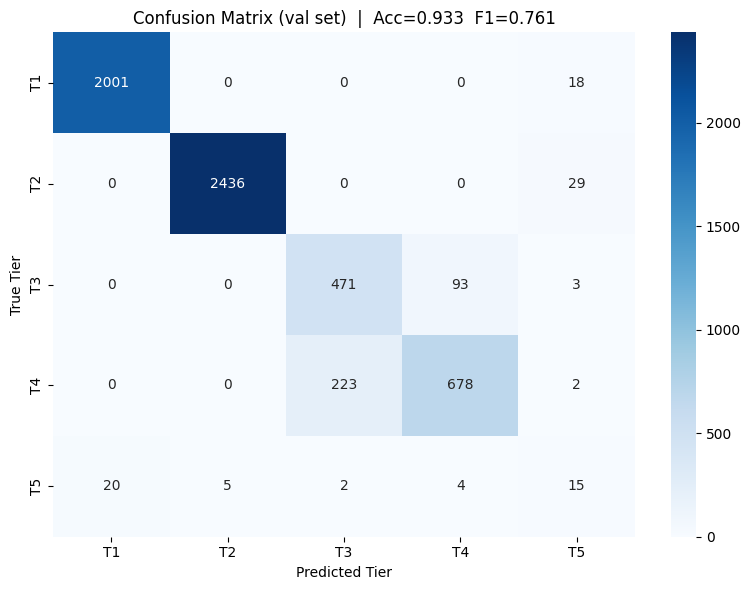

In [30]:
# Cell 9: Evaluation

y_pred      = model.predict(X_val)
y_pred_prob = model.predict_proba(X_val)

acc    = accuracy_score(y_val, y_pred)
f1_mac = f1_score(y_val, y_pred, average='macro')
f1_wt  = f1_score(y_val, y_pred, average='weighted')

# Macro OvR AUC
auc = roc_auc_score(y_val, y_pred_prob, multi_class='ovr', average='macro')

print('=' * 55)
print(f'  Accuracy:          {acc:.4f}')
print(f'  F1 (macro):        {f1_mac:.4f}')
print(f'  F1 (weighted):     {f1_wt:.4f}')
print(f'  AUC-ROC (macro):   {auc:.4f}')
print('=' * 55)

tier_labels = [f'T{i+1}' for i in range(5)]
print()
print(classification_report(
    y_val, y_pred,
    target_names=[CONFIG['tier_names'][i+1] for i in range(5)],
    digits=4
))

# Confusion matrix plot
cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=tier_labels, yticklabels=tier_labels)
ax.set_xlabel('Predicted Tier')
ax.set_ylabel('True Tier')
ax.set_title(f'Confusion Matrix (val set)  |  Acc={acc:.3f}  F1={f1_mac:.3f}')
plt.tight_layout()
plt.savefig(Path(CONFIG['model_dir']) / 'confusion_matrix.png', dpi=150)
plt.show()

Computing SHAP values (TreeExplainer)...


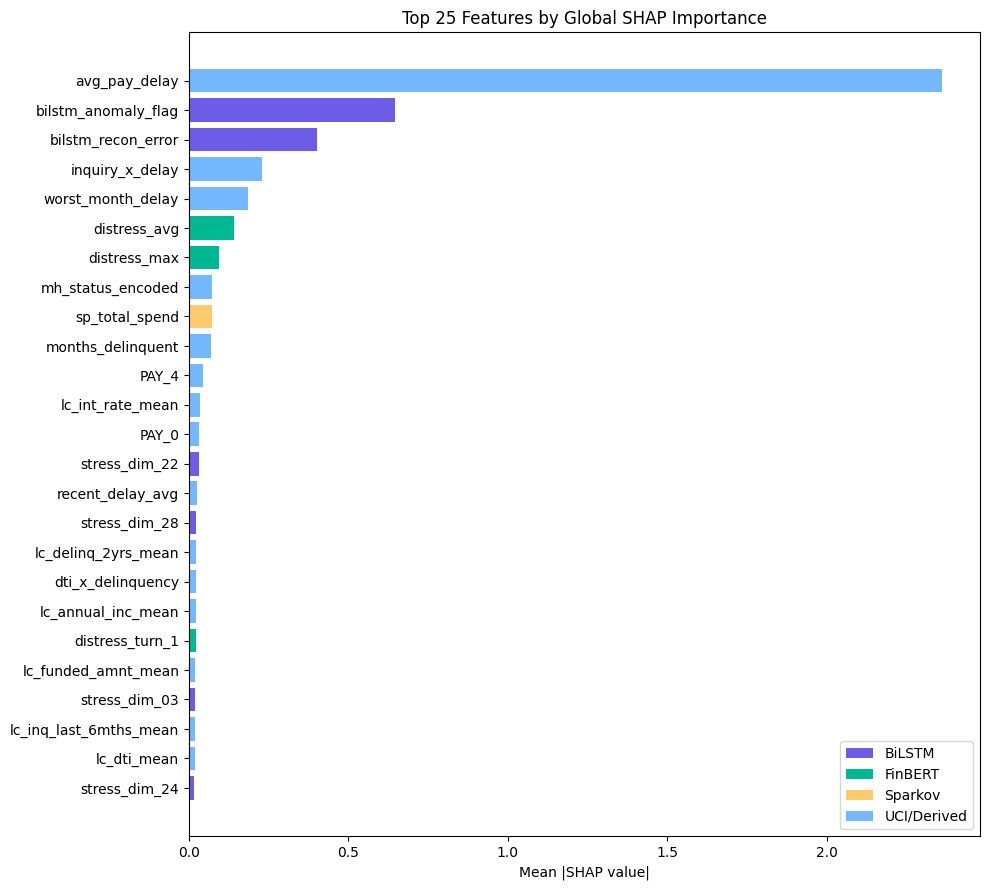


Top 10 features:
            feature      branch  mean_abs_shap
      avg_pay_delay UCI/Derived       2.362896
bilstm_anomaly_flag      BiLSTM       0.644883
 bilstm_recon_error      BiLSTM       0.400246
    inquiry_x_delay UCI/Derived       0.228573
  worst_month_delay UCI/Derived       0.184609
       distress_avg     FinBERT       0.140750
       distress_max     FinBERT       0.092751
  mh_status_encoded UCI/Derived       0.071793
     sp_total_spend     Sparkov       0.071385
  months_delinquent UCI/Derived       0.068804

Branch contribution (mean |SHAP|):
   UCI/Derived: 3.5958  (66.4%)
        BiLSTM: 1.4138  (26.1%)
       FinBERT: 0.2815  (5.2%)
       Sparkov: 0.1223  (2.3%)


In [31]:
# Cell 10: SHAP Feature Importance

print('Computing SHAP values (TreeExplainer)...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

# Mean absolute SHAP across all classes and samples → global importance
# shap_values shape: (n_classes, n_samples, n_features) or (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    # list of (n_samples, n_features) arrays, one per class
    mean_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=(0, -1)) if shap_values.ndim == 3 else np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({'feature': X_val.columns, 'mean_abs_shap': mean_shap})
shap_df = shap_df.sort_values('mean_abs_shap', ascending=False)

# Tag each feature by branch
def tag_branch(feat):
    if feat.startswith('stress_dim_') or feat.startswith('bilstm_'): return 'BiLSTM'
    if feat.startswith('distress_'):                                  return 'FinBERT'
    if feat.startswith('sp_'):                                        return 'Sparkov'
    return 'UCI/Derived'

shap_df['branch'] = shap_df['feature'].apply(tag_branch)

# Plot top 25
top25 = shap_df.head(25)
branch_colors = {'BiLSTM': '#6c5ce7', 'FinBERT': '#00b894', 'Sparkov': '#fdcb6e', 'UCI/Derived': '#74b9ff'}
colors = [branch_colors[b] for b in top25['branch']]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top25['feature'][::-1], top25['mean_abs_shap'][::-1], color=colors[::-1])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 25 Features by Global SHAP Importance')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=b) for b, c in branch_colors.items()]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(Path(CONFIG['model_dir']) / 'shap_importance.png', dpi=150)
plt.show()

print('\nTop 10 features:')
print(shap_df[['feature', 'branch', 'mean_abs_shap']].head(10).to_string(index=False))

print('\nBranch contribution (mean |SHAP|):')
branch_summary = shap_df.groupby('branch')['mean_abs_shap'].sum().sort_values(ascending=False)
total = branch_summary.sum()
for branch, val in branch_summary.items():
    print(f'  {branch:>12s}: {val:.4f}  ({val/total*100:.1f}%)')

In [32]:
# Cell 11: Save Model + Predictions

# Save XGBoost model
model_path = Path(CONFIG['model_dir']) / 'best_model.json'
model.save_model(model_path)
print(f'Model saved to: {model_path}')

# Attach predictions + probabilities to full dataset
all_pred      = model.predict(X)
all_pred_prob = model.predict_proba(X)

df['recovery_tier_pred'] = all_pred + 1  # back to 1-indexed
for i in range(5):
    df[f'tier_prob_{i+1}'] = all_pred_prob[:, i]

# Save output
df_output = df.copy()
df_output.to_csv(CONFIG['output_path'], index=False)

print(f'Output saved to: {CONFIG["output_path"]}')
print(f'Shape: {df_output.shape}')
print(f'New columns added: recovery_tier, recovery_tier_pred, tier_prob_1..5')

Model saved to: ../../../models/xgboost/best_model.json
Output saved to: ../../../data/processed/08_with_recovery_tiers.csv
Shape: (30000, 135)
New columns added: recovery_tier, recovery_tier_pred, tier_prob_1..5


In [33]:
# Cell 12: Save Manifest

manifest = {
    'notebook': '08_xgboost_recovery_tier',
    'output_file': CONFIG['output_path'],
    'model_checkpoint': str(model_path),
    'inputs': {
        'finbert_output': CONFIG['finbert_path'],
        'bilstm_output':  CONFIG['bilstm_path'],
    },
    'target': 'recovery_tier (1–5, rule-engineered)',
    'tier_definitions': CONFIG['tier_names'],
    'features': {
        'total': int(X.shape[1]),
        'bilstm_stress_dims': 32,
        'bilstm_meta': 2,
        'finbert_distress': len([c for c in X.columns if c.startswith('distress_')]),
        'sparkov': len([c for c in X.columns if c.startswith('sp_')]),
        'uci_derived': len([c for c in X.columns if not any(c.startswith(p) for p in ['stress_dim_','bilstm_','distress_','sp_'])]),
    },
    'metrics': {
        'accuracy':      round(float(acc),    4),
        'f1_macro':      round(float(f1_mac), 4),
        'f1_weighted':   round(float(f1_wt),  4),
        'auc_roc_macro': round(float(auc),    4),
        'best_round':    int(best_round),
        'best_val_mlogloss': round(float(best_score), 6),
    },
    'top_features_by_shap': shap_df[['feature','branch','mean_abs_shap']].head(10).to_dict('records'),
    'branch_shap_contribution': branch_summary.to_dict(),
    'split_source': CONFIG['split_path'],
    'xgb_params': CONFIG['xgb_params'],
}

with open(CONFIG['manifest_path'], 'w') as f:
    json.dump(manifest, f, indent=2, default=str)

print(f'Manifest saved to: {CONFIG["manifest_path"]}')
print()
print('=' * 55)
print('NOTEBOOK 08 COMPLETE')
print('=' * 55)

Manifest saved to: ../../../models/xgboost/xgboost_manifest.json

NOTEBOOK 08 COMPLETE


In [34]:
# Cell 13: Sanity Check

print('SANITY CHECK')
print('=' * 55)

df_check = pd.read_csv(CONFIG['output_path'])

print(f'1. Output readable:              OK — Shape {df_check.shape}')
print(f'2. recovery_tier present:        {"OK" if "recovery_tier" in df_check.columns else "FAIL"}')
print(f'3. recovery_tier_pred present:   {"OK" if "recovery_tier_pred" in df_check.columns else "FAIL"}')
print(f'4. Tier values in [1,5]:         {"OK" if df_check["recovery_tier"].between(1,5).all() else "FAIL"}')
print(f'5. No NaN in tier cols:          {"OK" if df_check[["recovery_tier","recovery_tier_pred"]].isna().sum().sum()==0 else "FAIL"}')
print(f'6. All 5 tiers present:          {"OK" if df_check["recovery_tier"].nunique()==5 else "FAIL"}')
print(f'7. Tier probs sum to ~1:         ', end='')
prob_sum = df_check[[f'tier_prob_{i}' for i in range(1,6)]].sum(axis=1)
print(f'{"OK" if (prob_sum - 1.0).abs().max() < 1e-4 else "FAIL"}')
print(f'8. customer_id present:          {"OK" if "customer_id" in df_check.columns else "FAIL"}')

print()
print('Final tier distribution (engineered labels):')
for tier, count in df_check['recovery_tier'].value_counts().sort_index().items():
    print(f'  Tier {tier}: {count:,} ({count/len(df_check)*100:.1f}%)')

print()
print('=' * 55)
print('Ready for B3.5 Audit Layer (Notebook 09)!')
print('=' * 55)

SANITY CHECK
1. Output readable:              OK — Shape (30000, 135)
2. recovery_tier present:        OK
3. recovery_tier_pred present:   OK
4. Tier values in [1,5]:         OK
5. No NaN in tier cols:          OK
6. All 5 tiers present:          OK
7. Tier probs sum to ~1:         OK
8. customer_id present:          OK

Final tier distribution (engineered labels):
  Tier 1: 10,167 (33.9%)
  Tier 2: 12,559 (41.9%)
  Tier 3: 2,715 (9.0%)
  Tier 4: 4,379 (14.6%)
  Tier 5: 180 (0.6%)

Ready for B3.5 Audit Layer (Notebook 09)!
